# Student Performance Analysis

## Objective

This project explores factors associated with students' exam performance and compares several regression models for predicting exam scores.

The analysis includes data cleaning, exploratory data analysis, visualization, categorical encoding, and introductory regression modeling.

## Dataset

The dataset contains 6,607 student records with academic, behavioral, and demographic variables.

## Workflow

1. Data loading and exploration
2. Missing-value analysis and cleaning
3. Exploratory data analysis and visualization
4. Categorical variable encoding
5. Train-test split
6. Regression model training
7. Model evaluation using MAE and R²




In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('StudentPerformanceFactors[1].csv')

In [49]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [50]:
print(df.isnull().sum())

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


In [51]:
before = df.shape[0]
df_clear = df.dropna()
after = df_clear.shape[0]
print(before - after, " rows were removed. Number of remaining rows: ", after)
print(df_clear.isnull().sum())

229  rows were removed. Number of remaining rows:  6378
Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64


In [52]:
mapping = {'Low' : 1, 'Medium' : 2, 'High' : 3}
# ML models cannot work directly with strings, so we convert the strings to integers.

df_clear[ 'Parental_Involvement' ] = df_clear[ 'Parental_Involvement' ].map(mapping)
df_clear[ 'Access_to_Resources' ] = df_clear[ 'Access_to_Resources' ].map(mapping)
df_clear[ 'Motivation_Level' ] = df_clear[ 'Motivation_Level' ].map(mapping)
df_clear[ 'Family_Income' ] = df_clear[ 'Family_Income' ].map(mapping)
df_clear[ 'Teacher_Quality' ] = df_clear[ 'Teacher_Quality' ].map(mapping)

/tmp/ipykernel_1337/1373317429.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clear[ 'Parental_Involvement' ] = df_clear[ 'Parental_Involvement' ].map(mapping)
/tmp/ipykernel_1337/1373317429.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clear[ 'Access_to_Resources' ] = df_clear[ 'Access_to_Resources' ].map(mapping)
/tmp/ipykernel_1337/1373317429.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value i

In [53]:
print(df_clear[['Hours_Studied', 'Attendance', 'Exam_Score', 'Physical_Activity', 'Previous_Scores', 'Sleep_Hours', 'Tutoring_Sessions']].dtypes)

Hours_Studied        int64
Attendance           int64
Exam_Score           int64
Physical_Activity    int64
Previous_Scores      int64
Sleep_Hours          int64
Tutoring_Sessions    int64
dtype: object


In [54]:
df_final = pd.get_dummies(df_clear, drop_first=True)
df_final.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,...,Internet_Access_Yes,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,23,84,1,3,7,73,1,0,1,2,...,True,True,False,True,False,True,False,False,True,True
1,19,64,1,2,8,59,1,2,2,2,...,True,True,False,False,False,False,False,True,False,False
2,24,98,2,2,7,91,2,2,2,2,...,True,True,True,False,False,False,True,False,True,True
3,29,89,1,2,8,98,2,1,2,2,...,True,True,False,False,False,True,False,True,False,True
4,19,92,2,2,6,65,2,3,2,3,...,True,True,True,False,False,False,False,False,True,False


In [55]:
print(df_final.info())

<class 'pandas.core.frame.DataFrame'>
Index: 6378 entries, 0 to 6606
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   Hours_Studied                          6378 non-null   int64
 1   Attendance                             6378 non-null   int64
 2   Parental_Involvement                   6378 non-null   int64
 3   Access_to_Resources                    6378 non-null   int64
 4   Sleep_Hours                            6378 non-null   int64
 5   Previous_Scores                        6378 non-null   int64
 6   Motivation_Level                       6378 non-null   int64
 7   Tutoring_Sessions                      6378 non-null   int64
 8   Family_Income                          6378 non-null   int64
 9   Teacher_Quality                        6378 non-null   int64
 10  Physical_Activity                      6378 non-null   int64
 11  Exam_Score                         

In [56]:
#our target is Exam_Score, so we separate the target (y) and features (x)
y = df_final[ 'Exam_Score'] # axis = 0 means from top to bottom
x = df_final.drop('Exam_Score', axis = 1) # axis = 1 means from left to right, so here we tell pandas to find the 'Exam_Score' COLUMN in the table and remove it completely from top to bottom.
print(y.head())
print(x.head())

0    67
1    61
2    74
3    71
4    70
Name: Exam_Score, dtype: int64
   Hours_Studied  Attendance  Parental_Involvement  Access_to_Resources  \
0             23          84                     1                    3   
1             19          64                     1                    2   
2             24          98                     2                    2   
3             29          89                     1                    2   
4             19          92                     2                    2   

   Sleep_Hours  Previous_Scores  Motivation_Level  Tutoring_Sessions  \
0            7               73                 1                  0   
1            8               59                 1                  2   
2            7               91                 2                  2   
3            8               98                 2                  1   
4            6               65                 2                  3   

   Family_Income  Teacher_Quality  ...  Inter

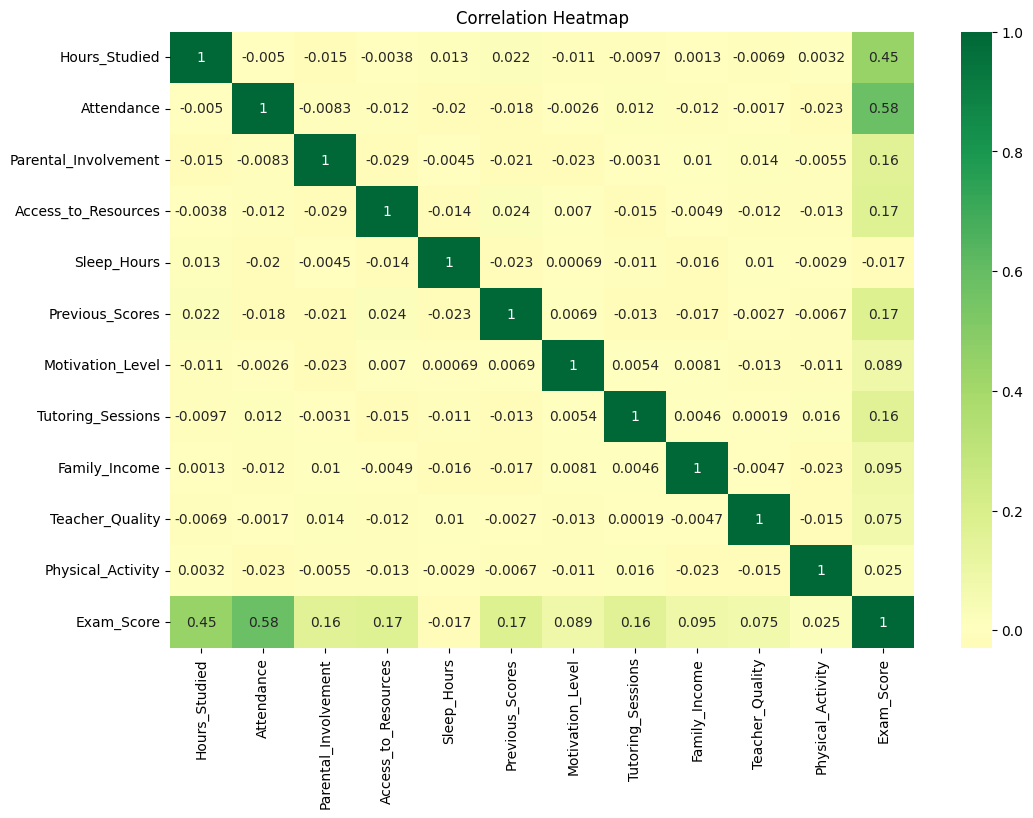

In [57]:
plt.figure(figsize=(12, 8))
#select only numerical columns
numeric_df = df_clear.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdYlGn', center=0)
plt.title('Correlation Heatmap')
plt.show() #positive correlation (0 to 1): the variables tend to increase together.
#weak correlation (close to 0): There is little to no linear relationship.
#negative correlation (0 to -1): The variables tend to move in opposite directions.

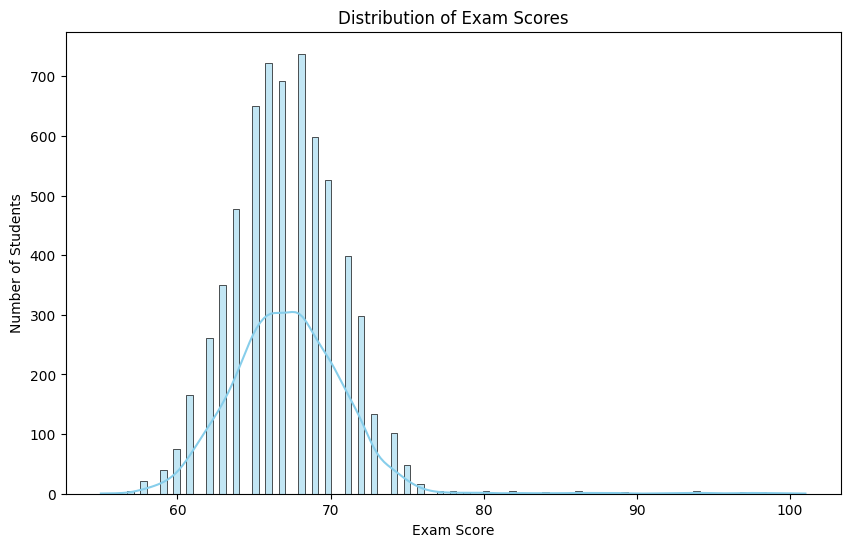

In [58]:
plt.figure(figsize=(10, 6)) #size of the graph: 10 = width, 6 = height
sns.histplot(df_clear['Exam_Score'], kde=True, color='skyblue') #looks at only one column
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Number of Students')
plt.show()

çubuklar, yani histogram grafiğimizden not yoğunluğunun 60 ve 75 arasında ve yaklaşık 68 puan civarında zirve yapmış olduğunu görüyoruz

yoğunluk tahmin çizgisi (kernel density estimate), histogram grafiğini yumuşatarak verinin genel dağılım trendini görmemizi sağlar. histogramdan daha alçakta olmasının sebebi çubuklar "kişi sayısını" sayarken, bu çizgi "olasılığı" hesaplar.

veri sağa doğru uzuyor ama kalabalık sol tarafta. bu da bize sınavın pek de "kolay" olmadığını, yüksek not almanın zor olduğunu gösteriyor.

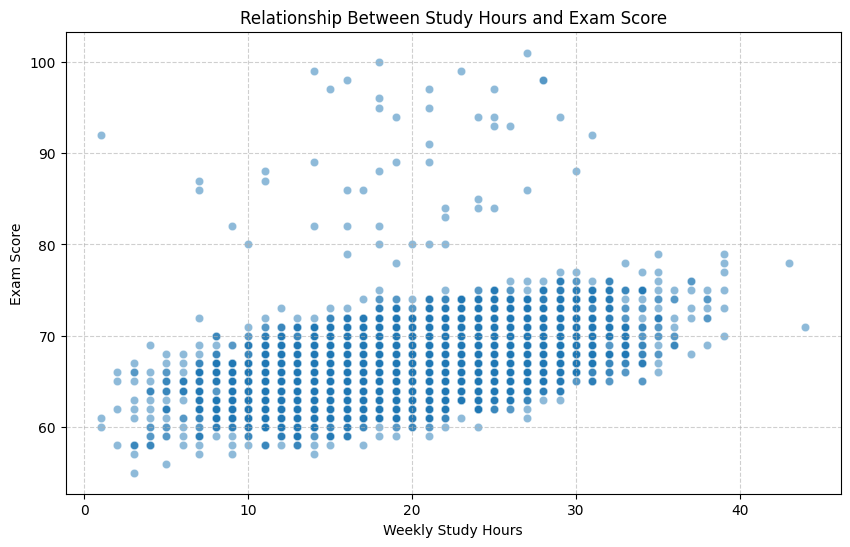

In [59]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=df_clear, alpha=0.5)
# alpha controls transparency: 0.5 = semi-transparent, 0 = fully transparent, 1 = fully opaque
# looks at two different numerical columns
plt.title('Relationship Between Study Hours and Exam Score')
plt.xlabel('Weekly Study Hours')
plt.ylabel('Exam Score')
plt.grid(True, linestyle='--', alpha=0.6) # adds helpful grid lines to the background
plt.show()

bu bir scatter plot (serpilme diagramı)
grafiğe uzaktan baktığımızda noktaların genel olarak soldan sağa doğru yukarı tırmandığını görebiliriz. bu, istatistikte pozitif korelasyon olarak adlandırılır.

sağ tarafta, 40 saate yakın çalışmasına rağmen hala 70 bandında kalanlar var. bu da bize "çok çalışmanın her zaman en yüksek puanı garanti etmediğini" söyler.
yani puanı belirleyen tek şey "çalışma saati" değil; zeka, uyku, sınav stresi gibi başka faktörler de devrede.

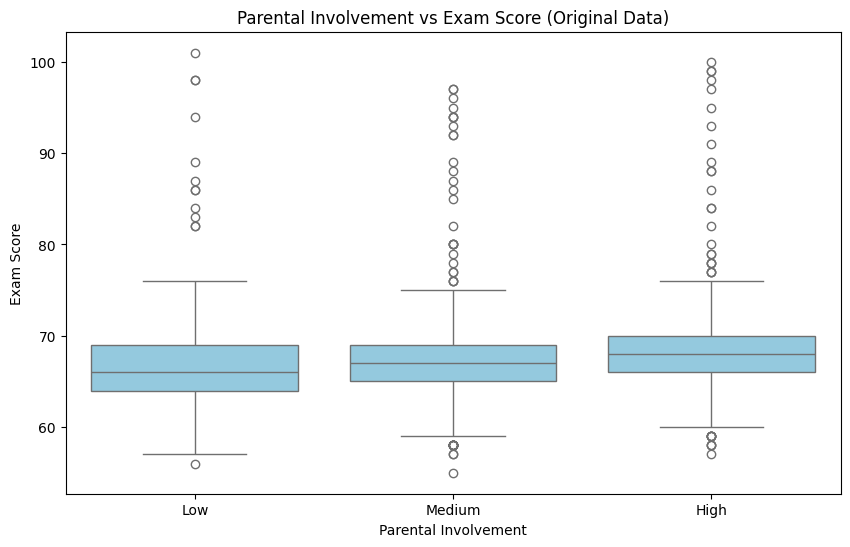

In [60]:
# step 1: load the data from scratch so we have the original variable names
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_fresh = pd.read_csv('StudentPerformanceFactors[1].csv') # check the file name
df_fresh.columns = df_fresh.columns.str.strip() # remove extra spaces from column names
df_fresh = df_fresh.dropna() # remove rows with missing values

# step 2: create the boxplot using this 'fresh' data
plt.figure(figsize=(10, 6))

# use the safest method to avoid color-related errors
sns.boxplot(x='Parental_Involvement',
            y='Exam_Score',
            data=df_fresh,
            order=['Low', 'Medium', 'High'],
            color='skyblue') # use a single color to avoid confusion

plt.title('Parental Involvement vs Exam Score (Original Data)')
plt.ylabel('Exam Score')
plt.xlabel('Parental Involvement')
plt.show()

box plot
low (düşük): medyan yaklaşık 66 civarında.

medium (orta): medyan yaklaşık 67 seviyesinde.

high (yüksek): medyan yaklaşık 68 civarında.

ebeveyn ilgisi arttıkça başarı artmış

kutuların genişliği (alt ve üst sınırları), verilerin %50'sinin bulunduğu alanı gösterir.
high (yüksek) grubunun kutusu, diğerlerine göre bir tık daha yukarıda konumlanmış durumda. bu, ebeveyn ilgisi yüksek olan çocukların puan tabanının biraz daha yukarıya çekildiğini gösteriyor.

aykırı değerler: high (yüksek) grubunun kutusu, diğerlerine göre bir tık daha yukarıda konumlanmış durumda. bu, ebeveyn ilgisi yüksek olan çocukların puan tabanının biraz daha yukarıya çekildiğini gösteriyor.


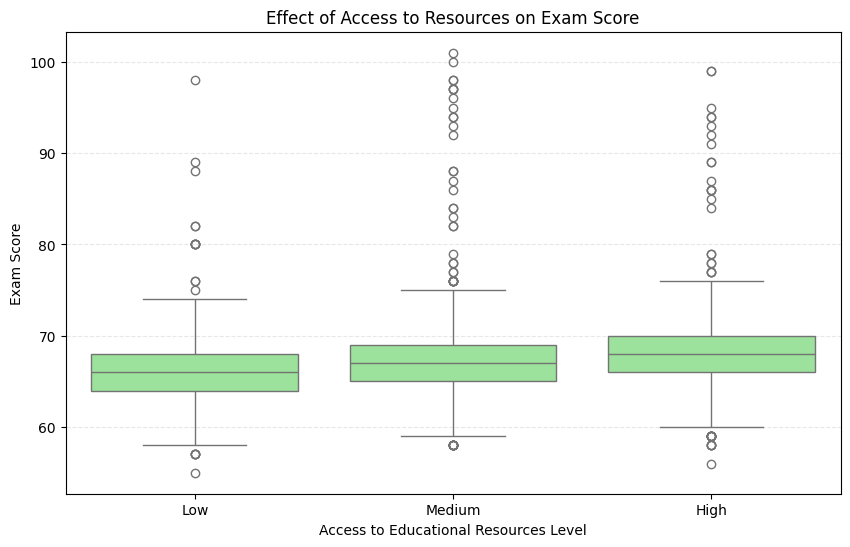

In [61]:
plt.figure(figsize=(10, 6))

#we use the 'color' parameter again to avoid color-related errors
#you can choose any color you like, such as 'lightgreen' or 'salmon'
sns.boxplot(x='Access_to_Resources',
            y='Exam_Score',
            data=df_fresh,
            order=['Low', 'Medium', 'High'],
            color='lightgreen')

plt.title('Effect of Access to Resources on Exam Score')
plt.ylabel('Exam Score')
plt.xlabel('Access to Educational Resources Level')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

low (düşük): medyan yaklaşık 66 civarında.

medium (orta): medyan yaklaşık 67 seviyesinde.

high (yüksek): medyan yaklaşık 68 civarında.

kaynak arttıkça başarı artmış

aykırı değerler: kaynak erişimi "low" (düşük) olan grupta bile 100 tam puana yaklaşan (yaklaşık 98 puan) bir öğrenci var.


orta ("medium") gruptaki aykırı değerlerin (başarılı öğrencilerin) sayısı, "high" grubundan daha yoğun görünüyor. bu, çok fazla kaynağa sahip olmanın tek başına "en iyisi" olmayı garantilemediğini, orta düzey kaynağın da zirveye çıkmak için yeterli olabileceğini gösteriyor.


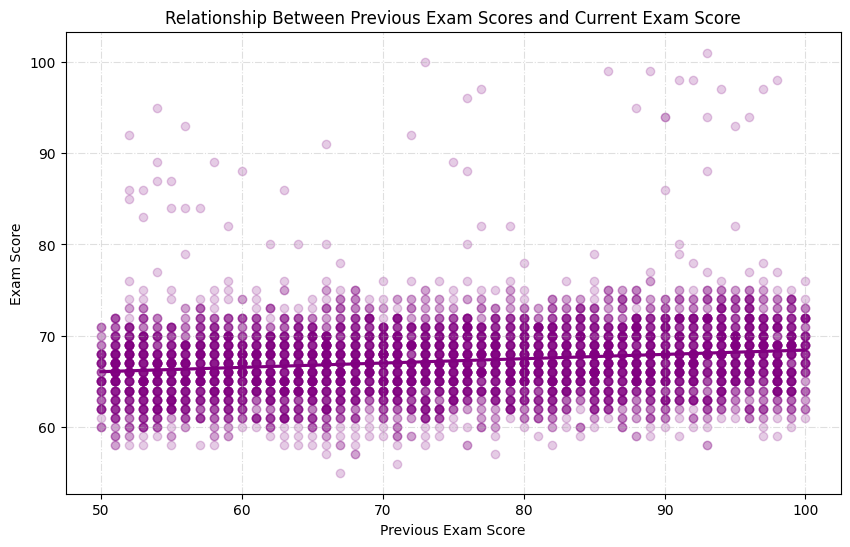

In [62]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Previous_Scores', y='Exam_Score', data=df_clear, scatter_kws={'alpha':0.2}, color='purple')
plt.title('Relationship Between Previous Exam Scores and Current Exam Score')
plt.xlabel('Previous Exam Score')
plt.ylabel('Exam Score')
plt.grid(True, linestyle='-.', alpha=0.4)
plt.show()

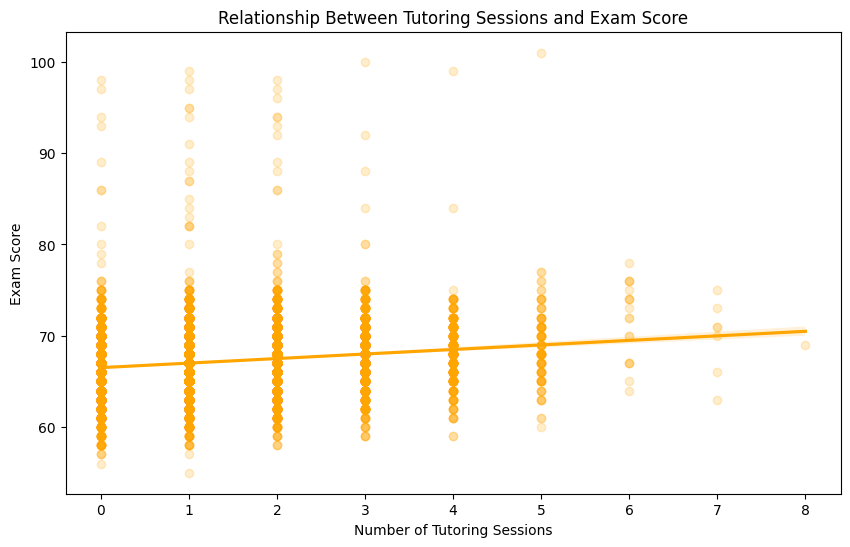

In [63]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Tutoring_Sessions', y='Exam_Score', data=df_clear, scatter_kws={'alpha':0.2}, color='orange')
plt.title('Relationship Between Tutoring Sessions and Exam Score')
plt.xlabel('Number of Tutoring Sessions')
plt.ylabel('Exam Score')
plt.show()

lineer regresyon: eğer ilişki doğrusal ise en basit ve hızlı yöntemdir.

karar ağaçları (decision trees): kategorik verilerle (low/medium/high) çok iyi çalışır.

random forest: verideki "aykırı değerleri" (grafikteki o uç noktaları) daha iyi yönetebilir.

lineer regresyon: eğer çizdiğimiz o regplot grafiklerindeki noktalar düz bir çizgiye çok yakın dizildiyse bu model genellikle yeterli olur. basit ve hızlıdır.

karar ağaçları (decision trees): eğer veride "eğer ebeveyn ilgisi high ise VE çalışma saati 10'dan büyükse puanı 80 yap" gibi net kırılmalar varsa bu model çok başarılıdır.

random forest: veride çok fazla gürültü veya kafa karıştırıcı uç nokta varsa kullanılır. yüzlerce küçük karar ağacını birleştirip "ortak akıl" yürüttüğü için hata payı genellikle en düşük olandır.

In [64]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. load and clean the data
df_final = pd.read_csv('StudentPerformanceFactors[1].csv')
df_final = df_final.dropna()
df_final.columns = df_final.columns.str.strip()

# 2. convert categorical data to numerical values (0 and 1)
df_numeric = pd.get_dummies(df_final, drop_first=True)

# 3. separate the target and features
y = df_numeric['Exam_Score']
X = df_numeric.drop('Exam_Score', axis=1)

# 4. split the data (X_train is defined here)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. define the models
modeller = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

# 6. start the competition
print("Comparing Model Results...\n")
for isim, model in modeller.items():
    model.fit(X_train, y_train) # train
    y_pred = model.predict(X_test) # make predictions

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"--- {isim} ---")
    print(f"Mean Absolute Error (MAE): {mae:.2f} points") # MAE (Mean Absolute Error)
    print(f"Performance (R2): %{r2*100:.2f}\n") # R2 Score (Coefficient of Determination)

    # linear regression was the best-performing model because it had the lowest MAE (0.49) and the highest R2 score (73.14%)

Comparing Model Results...

--- Linear Regression ---
Mean Absolute Error (MAE): 0.49 points
Performance (R2): %73.14

--- Decision Tree ---
Mean Absolute Error (MAE): 1.85 points
Performance (R2): %16.55

--- Random Forest ---
Mean Absolute Error (MAE): 1.25 points
Performance (R2): %61.09



In [65]:
#let's redefine and train the champion model (linear regression)
final_model = LinearRegression()
final_model.fit(X_train, y_train)

#let's make a sample prediction (you can change these values too!)
#note: X_test.iloc[0] represents the data of the first student
ornegin_verisi = X_test.iloc[[0]]
tahmin = final_model.predict(ornegin_verisi)

print(f"Student's Actual Score: {y_test.iloc[0]}")
print(f"Model's Prediction: {tahmin[0]:.2f}")

Student's Actual Score: 74
Model's Prediction: 73.97


In [66]:
# let's make a new prediction using linear regression
import numpy as np

# first, let's see the column names so we know what values to assign
#print(X.columns) # run this to see which columns are available

# EXAMPLE: random student data (let's select one from the test set)
index = 10 # we selected the student at index 10
ogrenci_verisi = X_test.iloc[[index]] # iloc: index location
# X_test.iloc[10] returns the 11th student (since counting starts from 0).
gercek_puan = y_test.iloc[index]
tahmin_puan = modeller["Linear Regression"].predict(ogrenci_verisi)

print(f"--- Analysis of the Student at Index 10 ---")
print(f"Actual Score: {gercek_puan}")
print(f"Model's Prediction: {tahmin_puan[0]:.2f}")
print(f"Error Margin: {abs(gercek_puan - tahmin_puan[0]):.2f} points")

--- Analysis of the Student at Index 10 ---
Actual Score: 62
Model's Prediction: 62.55
Error Margin: 0.55 points


--- How Much Does Each Factor Affect the Score? ---
                                   Factor  Effect Magnitude
20                Peer_Influence_Positive          1.014880
13                    Internet_Access_Yes          0.900608
25                Distance_from_Home_Near          0.841829
10         Extracurricular_Activities_Yes          0.566723
19                 Peer_Influence_Neutral          0.561867
23  Parental_Education_Level_Postgraduate          0.521576
4                       Tutoring_Sessions          0.482777
24            Distance_from_Home_Moderate          0.304964
0                           Hours_Studied          0.295834
5                       Physical_Activity          0.200224
1                              Attendance          0.198689
18                     School_Type_Public          0.048959
3                         Previous_Scores          0.048514
26                            Gender_Male         -0.010802
2                             Sleep_Hours       

/tmp/ipykernel_1337/2927230796.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Effect Magnitude', y='Factor', data=katsayilar, palette='RdYlGn')


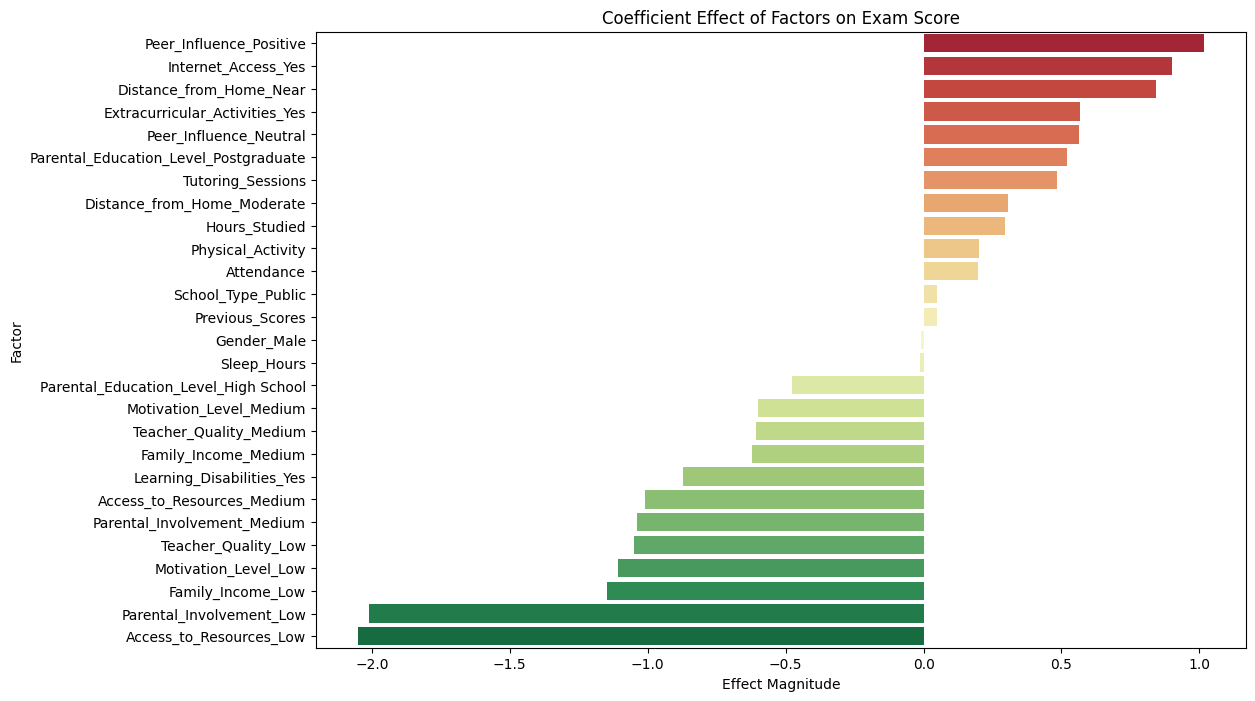

In [67]:
#let's convert the model coefficients (importance) into a table

katsayilar = pd.DataFrame({'Factor': X.columns, 'Effect Magnitude': modeller["Linear Regression"].coef_}).sort_values(by='Effect Magnitude', ascending=False)
print("--- How Much Does Each Factor Affect the Score? ---")
print(katsayilar)
#let's visualize it
plt.figure(figsize=(12, 8))
sns.barplot(x='Effect Magnitude', y='Factor', data=katsayilar, palette='RdYlGn')
plt.title('Coefficient Effect of Factors on Exam Score')
plt.show()

#if the coefficient is positive, the score increases; if it is negative, the score decreases.
#for example, Internet Access increases the score by nearly 1 point.

In [68]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
